# Crop Yield Prediction for Food Security in Africa.

## 1.Business Understanding

### 1.1 Project Overview 

Agriculture plays an important role in providing food and supporting the economy in many African countries. However, many farmers find it difficult to estimate how much crop they will harvest before planting, and this can in turn lead to poor planning, low productivity, and financial losses.

The aim of this project is to build a machine learning system that predicts crop yield using soil information such as pH, nitrogen, phosphorus, potassium, soil moisture, and field size. This will help farmers make better farming decisions and improve food security.

### 1.2 Stakeholders.
##### The key statekeholders for this project are:
* Farmers and Farmer groups.
* Government Institutions.
* NGOs and development partners.
* Farm inputs providers and suppliers.
* Market Actors.
* Research Institutions and Academia.
* Food Security and Warning bodies.
* Financial Institutions & insurers.
* Consumers.

### 1.3 Business Problem
Food insecurity remains a major challenge in many African countries. Farmers often make planting decisions without knowing how much they are likely to harvest. This can lead to poor planning, inefficient use of fertilizers and other resources, and lower crop production. As a result, farmers may experience financial losses, while governments and agricultural organizations find it difficult to plan for future food needs. Thus creating a need for a a reliable system that can help predict crop yield before planting using soil data.

### 1.4 Objectives
* Develop a machine learning model that can accurately predict crop yield based on soil health indicators and field characteristics.

* Help farmers make informed farming decisions by predicting the expected yield of their selected crop before planting.

* Provide insights that can support farmers, agricultural organizations, and governments in improving agricultural productivity and food security.

## 2. Data Understanding

### 2.1 Import Libraries

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [83]:
import os

# create images folder in the same location as the  notebook
os.makedirs("images", exist_ok=True)
print("images/ folder created")

images/ folder created


### 2.2 Load Data

In [84]:
# load data
df = pd.read_excel('../data/Editted2.xlsx')
df_copy = df.copy()
df.head()

,Crop Name,Target Yield,Field Size,pH (water),Organic Carbon,Total Nitrogen,Phosphorus (M3),Potassium (exch.),Soil moisture,Organic Matter Need,Lime Need
0,coffee (green beans),6400,1.00,5.5,25.9,1.9,2.0,3.8,17.4,605.0,325.0
1,coffee (green beans),2000,0.75,5.6,29.4,2.2,7.0,4.4,18.8,440.0,245.0
2,potato,35000,2.50,6.0,37.2,3.9,30.5,6.9,20.2,1260.0,745.0
3,cabbage,60000,2.50,6.0,37.2,3.9,30.5,6.9,20.2,1260.0,745.0
4,peas,4500,2.50,6.0,37.2,3.9,30.5,6.9,20.2,1260.0,745.0


### 2.3 Data Exploration

The Units for the dataset include:
* Target Yield unit- Kg
* Field size unit- acre
* Organic carbon- g/kg
* Nitrogen- g/kg
* Phosphorus- mg/kg
* Potassium- mmol+/kg
* Soil moisture- % (percentage)
* Organic matter- kg
* Lime-kg
* pH- pH value

In [85]:
print(df.columns)

Index(['Crop Name', 'Target Yield', 'Field Size', 'pH (water)',
       'Organic Carbon', 'Total Nitrogen', 'Phosphorus (M3)',
       'Potassium (exch.)', 'Soil moisture', 'Organic Matter Need',
       'Lime Need'],
      dtype='object')


In [86]:
print(df.shape)

(13802, 11)


In [87]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13802 entries, 0 to 13801
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Crop Name            13802 non-null  object 
 1   Target Yield         13802 non-null  int64  
 2   Field Size           13802 non-null  float64
 3   pH (water)           13776 non-null  float64
 4   Organic Carbon       13768 non-null  float64
 5   Total Nitrogen       13768 non-null  float64
 6   Phosphorus (M3)      13773 non-null  float64
 7   Potassium (exch.)    13773 non-null  float64
 8   Soil moisture        9655 non-null   float64
 9   Organic Matter Need  13768 non-null  float64
 10  Lime Need            13774 non-null  float64
dtypes: float64(9), int64(1), object(1)
memory usage: 1.2+ MB
None


In [88]:
df_missing = df.isnull().sum()
df_missing

Crop Name                 0
Target Yield              0
Field Size                0
pH (water)               26
Organic Carbon           34
Total Nitrogen           34
Phosphorus (M3)          29
Potassium (exch.)        29
Soil moisture          4147
Organic Matter Need      34
Lime Need                28
dtype: int64

In [89]:
df_null = df.isnull().sum() / len(df) * 100
df_null

Crop Name               0.000000
Target Yield            0.000000
Field Size              0.000000
pH (water)              0.188378
Organic Carbon          0.246341
Total Nitrogen          0.246341
Phosphorus (M3)         0.210114
Potassium (exch.)       0.210114
Soil moisture          30.046370
Organic Matter Need     0.246341
Lime Need               0.202869
dtype: float64

### To find at least top 20 crop that consist of 30% missing value

In [90]:
summary = (
    df.groupby('Crop Name')['Soil moisture']
      .agg(
          Total='size',
          Missing=lambda x: x.isna().sum()
      )
)

summary['Missing %'] = (
    summary['Missing'] / summary['Total'] * 100
).round(2)

summary = summary.sort_values('Missing %', ascending=False)

summary.head(20)

,Total,Missing,Missing %
Crop Name,,,
timber (general),4,4.0,100.00
kiwi,6,6.0,100.00
mature cacao,4,4.0,100.00
stevia,5,4.0,80.00
groundnut,81,61.0,75.31
rapeseed (canola),3,2.0,66.67
mango,259,171.0,66.02
garlic,89,58.0,65.17
beet root,8,5.0,62.50


In [91]:
df.describe()

,Target Yield,Field Size,pH (water),Organic Carbon,Total Nitrogen,Phosphorus (M3),Potassium (exch.),Soil moisture,Organic Matter Need,Lime Need
count,1.380200e+04,13802.000000,13776.000000,13768.000000,13768.000000,13773.000000,13773.000000,9655.000000,1.376800e+04,1.377400e+04
mean,2.388100e+04,123.463307,6.361474,25.417940,2.271426,12.879416,6.755718,15.568058,4.133714e+05,2.581598e+04
std,3.808466e+05,7185.915011,0.737447,22.254906,2.214835,14.399338,5.422551,8.045762,2.423067e+07,1.773352e+06
min,1.000000e+00,0.001000,4.490000,0.900000,0.100000,0.300000,0.300000,0.800000,0.000000e+00,0.000000e+00
25%,1.200000e+03,0.500000,5.800000,11.900000,1.100000,4.400000,3.000000,8.300000,3.050000e+02,5.000000e+01
50%,4.500000e+03,1.000000,6.380000,19.900000,1.800000,8.300000,5.100000,15.800000,7.800000e+02,1.550000e+02
75%,2.000000e+04,2.000000,6.890000,31.400000,2.700000,15.700000,9.000000,21.700000,1.630000e+03,3.200000e+02
max,4.111111e+07,589674.000000,8.460000,327.200000,24.900000,236.900000,43.400000,50.700000,2.007840e+09,1.468288e+08


In [92]:
# checking for duplicates

df.duplicated().sum()

6

In [93]:
# checking duplicate rows

dups = df[df.duplicated(keep=False)]
dups

,Crop Name,Target Yield,Field Size,pH (water),Organic Carbon,Total Nitrogen,Phosphorus (M3),Potassium (exch.),Soil moisture,Organic Matter Need,Lime Need
4413,maize (corn),360,2.000,6.5,3.4,0.3,8.4,0.7,6.4,1250.0,30.0
4434,maize (corn),360,2.000,6.5,3.4,0.3,8.4,0.7,6.4,1250.0,30.0
12850,onion,25000,1.000,6.6,11.0,1.0,16.6,10.5,4.8,1240.0,75.0
12851,onion,25000,1.000,6.6,11.0,1.0,16.6,10.5,4.8,1240.0,75.0
12852,onion,25000,1.000,6.6,11.0,1.0,16.6,10.5,4.8,1240.0,75.0
12853,onion,25000,1.000,6.6,11.0,1.0,16.6,10.5,4.8,1240.0,75.0
13705,tomato,24000,3.000,6.2,6.9,0.8,0.7,1.9,2.8,4015.0,345.0
13711,tomato,24000,3.000,6.2,6.9,0.8,0.7,1.9,2.8,4015.0,345.0
13736,maize (corn),400,0.125,7.0,29.1,2.5,17.7,10.1,13.7,70.0,20.0
13737,maize (corn),400,0.125,7.0,29.1,2.5,17.7,10.1,13.7,70.0,20.0


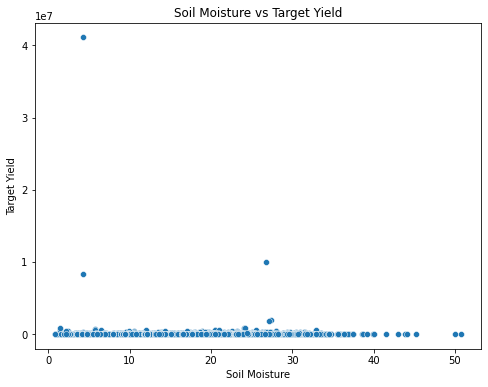

In [94]:
# Check for outliers
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="Soil moisture",
    y="Target Yield"
)

plt.title("Soil Moisture vs Target Yield")
plt.xlabel("Soil Moisture")
plt.ylabel("Target Yield")

plt.show()

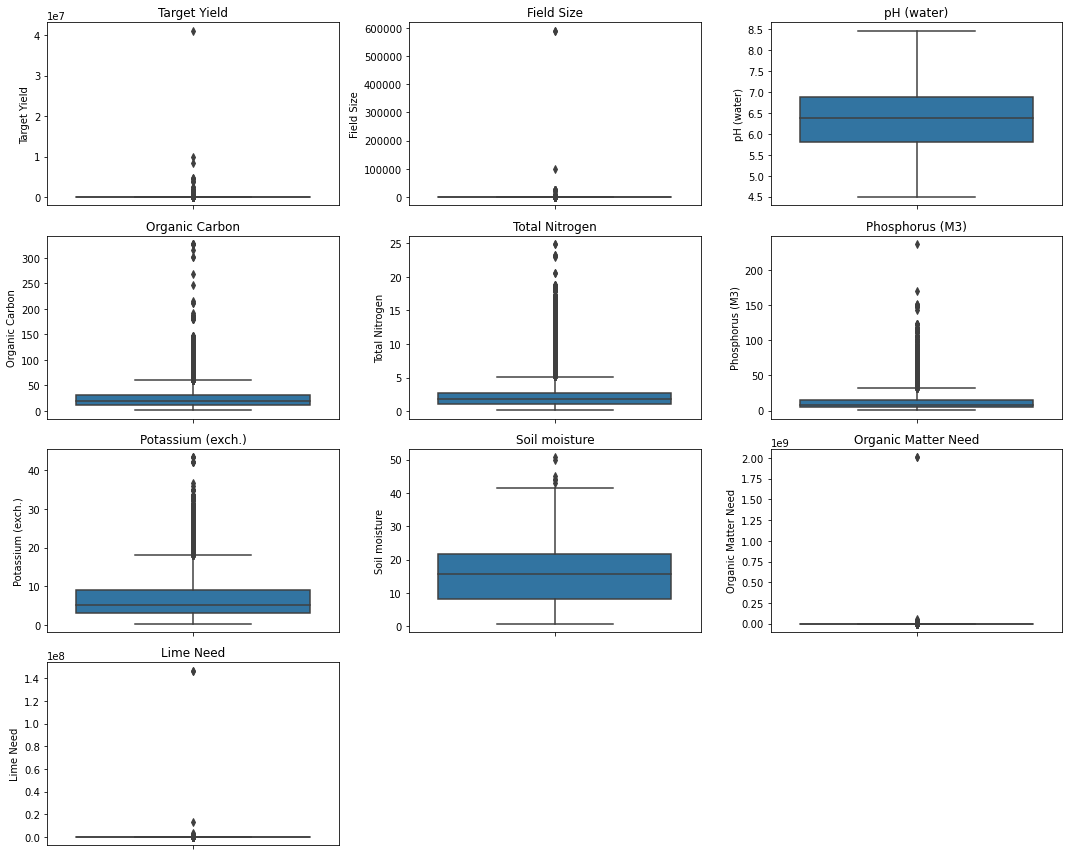

In [95]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(15, 12))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

##### Identifying Outliers

In [96]:
# Top 20 rows by Target Yield

print(df.nlargest(20, 'Target Yield')[['Crop Name', 'Target Yield', 'Field Size']])

print()

                     Crop Name  Target Yield  Field Size
12192                     oats      41111111     3629.00
971       coffee (green beans)      10000000        8.00
12193                beet root       8333333     3629.00
7832             passion fruit       4800000      160.00
7834                    papaya       4800000      160.00
7789                field bean       4500000        2.50
7823                   cabbage       4000000      160.00
7824                    orange       3840000      160.00
7833                     onion       2560000      160.00
7825                  chillies       2400000      160.00
275       coffee (green beans)       2000000        0.25
296       coffee (green beans)       1850000        2.50
7796                     melon       1500000        0.25
9250   tree tomato (tamarillo)       1250000        7.00
7690             passion fruit       1200000        1.00
7795                    orange       1200000        0.25
13792                    vetch 

In [97]:
# Top 20 rows by Field Size

print(df.nlargest(20, 'Field Size')[['Crop Name', 'Target Yield', 'Field Size']])

            Crop Name  Target Yield  Field Size
12183         soybean          1542    589674.0
12184          grapes         13200    589674.0
12489         avocado        100000    100000.0
10151       sugarcane         80000     23950.0
10152       sugarcane         80000     23950.0
10153       sugarcane         80000     23950.0
10155       sugarcane         80000     23950.0
10163       sugarcane         80000     23950.0
10188       sugarcane         80000     23950.0
10192       sugarcane         80000     23950.0
10197       sugarcane         80000     23950.0
10203       sugarcane         80000     23950.0
10206       sugarcane         80000     23950.0
10207       sugarcane         80000     23950.0
12191     melon-water          8669     21133.0
943           cabbage         10000     10000.0
12188  linseed (flax)        555555      8655.0
12189       butternut         59999      8655.0
12190         tobacco          5653      8655.0
12195          stevia          6134     

In [98]:
# Here we will identify outliers using the IQR method

# Calculate IQR for Target Yield
yield_q1 = df["Target Yield"].quantile(0.25)
yield_q3 = df["Target Yield"].quantile(0.75)
yield_iqr = yield_q3 - yield_q1

yield_lower = yield_q1 - 1.5 * yield_iqr
yield_upper = yield_q3 + 1.5 * yield_iqr

# Calculate IQR for Field Size
field_q1 = df["Field Size"].quantile(0.25)
field_q3 = df["Field Size"].quantile(0.75)
field_iqr = field_q3 - field_q1

field_lower = field_q1 - 1.5 * field_iqr
field_upper = field_q3 + 1.5 * field_iqr

# Identify rows that are outliers in either Target Yield or Field Size
outlier_mask = (
    (df["Target Yield"] < yield_lower) |
    (df["Target Yield"] > yield_upper) |
    (df["Field Size"] < field_lower) |
    (df["Field Size"] > field_upper)
)

# Display outlier information before removing them
print("Rows to remove:", outlier_mask.sum())
print("Rows remaining:", len(df) - outlier_mask.sum())
print("Percentage removed:", round(outlier_mask.sum() / len(df) * 100, 2), "%")

Rows to remove: 1863
Rows remaining: 11939
Percentage removed: 13.5 %


**Data quality issues**

- Extreme outliers: Target Yield maxes at 41,111,111 while the 99th percentile is only 200,000 — almost certainly a handful of data-entry errors or unit mismatches, not real values. Same story for Field Size (max ~589,674 vs. 99th percentile ~15). These need manual inspection — I'd pull the top 10–20 rows by each and decide whether to fix, cap, or drop them.

- Soil moisture is missing in ~30% of rows (4,147/13,802) — needs an imputation strategy or explicit handling.



### 2.3 Data Cleaning

#### a) Dropping duplicates

In [99]:
# drop duplicates
df = df.drop_duplicates()
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
13797    False
13798    False
13799    False
13800    False
13801    False
Length: 13796, dtype: bool

##### b) Handling Misssing values in Soil Moisture column

In order to determine the best way to handle the missing values, three options were considered as follows;

    Option 1: K- nearest neighbors

    Option 2: Random forest

    Option 3: XGBoost
    

Thereafter, we computed MAE, RMSE and R-squared for each of the three options then the model with the highest R-Squared and the least MAE and RMSE was selected

##### Option 1: KNN 

In [100]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
#Select the variables
cols = [
    "Target Yield",
    "Field Size",
    "pH (water)",
    "Organic Carbon",
    "Total Nitrogen",
    "Phosphorus (M3)",
    "Potassium (exch.)",
    "Organic Matter Need",
    "Lime Need",
    "Soil moisture"
]
#Keep only complete cases
complete = df[cols].dropna().copy()
#Randomly mask 20% of Soil moisture
np.random.seed(42)

mask = np.random.rand(len(complete)) < 0.20

original_values = complete.loc[mask, "Soil moisture"].copy()

complete.loc[mask, "Soil moisture"] = np.nan
#Apply KNN Imputation
scaler = StandardScaler()

scaled = scaler.fit_transform(complete)

imputer = KNNImputer(n_neighbors=5)

imputed = imputer.fit_transform(scaled)

imputed = scaler.inverse_transform(imputed)

imputed_df = pd.DataFrame(imputed, columns=cols)
#Evaluate the imputation
predicted = imputed_df.loc[mask, "Soil moisture"]

mse = mean_squared_error(original_values, predicted)
rmse = np.sqrt(mse)
r2 = r2_score(original_values, predicted)

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Squared Error (MSE): 28.155463424518743
Root Mean Squared Error (RMSE): 5.306172200797741
R² Score: 0.5596402428458274


##### Option 2: Random Forest model

In [101]:
from sklearn.ensemble import RandomForestRegressor

# Start from original data
df_rf = df.copy()

predictors = [
    'pH (water)',
    'Organic Carbon',
    'Total Nitrogen',
    'Phosphorus (M3)',
    'Potassium (exch.)',
    'Field Size'
]

# Split rows
known = df_rf[
    df_rf['Soil moisture'].notna()
]

missing = df_rf[
    df_rf['Soil moisture'].isna()
]

# Training rows must have complete predictors
train = known[
    predictors + ['Soil moisture']
].dropna()

fillable = missing[
    predictors
].dropna()

print("Training rows:", len(train))
print("Rows to predict:", len(fillable))

# Train Random Forest regressor
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    train[predictors],
    train['Soil moisture']
)

# Predict missing values
pred = rf.predict(
    fillable[predictors]
)

# Fill values
df_rf.loc[
    fillable.index,
    'Soil moisture'
] = pred

# Remaining missing → median
df_rf['Soil moisture'] = (
    df_rf['Soil moisture']
    .fillna(
        df_rf['Soil moisture'].median()
    )
)

# Summary
print(
    df_rf['Soil moisture']
    .describe()
)

Training rows: 9649
Rows to predict: 4113
count    13796.000000
mean        16.142012
std          7.223059
min          0.800000
25%         10.500000
50%         16.600000
75%         21.300000
max         50.700000
Name: Soil moisture, dtype: float64


In [102]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

train_pred = rf.predict(
    train[predictors]
)

mae = mean_absolute_error(
    train['Soil moisture'],
    train_pred
)

mse = mean_squared_error(
    train['Soil moisture'],
    train_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    train['Soil moisture'],
    train_pred
)

print("R² Score :", round(r2,3))
print("MAE      :", round(mae,3))
print("MSE      :", round(mse,3))
print("RMSE     :", round(rmse,3))

R² Score : 0.796
MAE      : 2.623
MSE      : 13.196
RMSE     : 3.633


#### Option 3: XGboost

In [103]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from xgboost import XGBRegressor
import numpy as np

# Data for evaluation
predictors = [
    'pH (water)',
    'Organic Carbon',
    'Total Nitrogen',
    'Phosphorus (M3)',
    'Potassium (exch.)',
    'Field Size'
]

known = df[
    predictors + ['Soil moisture']
].dropna()

X = known[predictors]
y = known['Soil moisture']

# Holdout validation
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train
xgb = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train, y_train)

# Predict
pred = xgb.predict(X_test)

# Metrics
mae = mean_absolute_error(
    y_test,
    pred
)

mse = mean_squared_error(
    y_test,
    pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    pred
)

print("MAE :", round(mae,3))
print("MSE :", round(mse,3))
print("RMSE:", round(rmse,3))
print("R²  :", round(r2,3))

MAE : 3.702
MSE : 24.683
RMSE: 4.968
R²  : 0.619


**Conclusion**

Based on the model outputs above, the Random Forest model was selected as the best to predict and impute the missing values for the "Soil Moisture" feature as it was the best performing model overall with the folowing metrics:

R² Score : 0.796
MAE      : 2.623
MSE      : 13.196
RMSE     : 3.633

##### Filling missing values with median


In [104]:
cols_to_impute = [
    "pH (water)",
    "Organic Carbon",
    "Total Nitrogen",
    "Phosphorus (M3)",
    "Potassium (exch.)",
    "Organic Matter Need",
    "Lime Need"
]

# Impute using the median within each crop
df[cols_to_impute] = (
    df.groupby("Crop Name")[cols_to_impute]
      .transform(lambda x: x.fillna(x.median()))
)

In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 13796 entries, 0 to 13801
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Crop Name            13796 non-null  object 
 1   Target Yield         13796 non-null  int64  
 2   Field Size           13796 non-null  float64
 3   pH (water)           13796 non-null  float64
 4   Organic Carbon       13796 non-null  float64
 5   Total Nitrogen       13796 non-null  float64
 6   Phosphorus (M3)      13796 non-null  float64
 7   Potassium (exch.)    13796 non-null  float64
 8   Soil moisture        9649 non-null   float64
 9   Organic Matter Need  13796 non-null  float64
 10  Lime Need            13796 non-null  float64
dtypes: float64(9), int64(1), object(1)
memory usage: 1.3+ MB


##### Fill the null values in Soil Moisture column

In [106]:
df['Soil moisture'] = known['Soil moisture']
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 13796 entries, 0 to 13801
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Crop Name            13796 non-null  object 
 1   Target Yield         13796 non-null  int64  
 2   Field Size           13796 non-null  float64
 3   pH (water)           13796 non-null  float64
 4   Organic Carbon       13796 non-null  float64
 5   Total Nitrogen       13796 non-null  float64
 6   Phosphorus (M3)      13796 non-null  float64
 7   Potassium (exch.)    13796 non-null  float64
 8   Soil moisture        9649 non-null   float64
 9   Organic Matter Need  13796 non-null  float64
 10  Lime Need            13796 non-null  float64
dtypes: float64(9), int64(1), object(1)
memory usage: 1.3+ MB


In [107]:
# Replace the Soil moisture column in the original dataframe
df['Soil moisture'] = df_rf['Soil moisture']

# Check that there are no missing values
print(df['Soil moisture'].isna().sum())

# Summary
print(df['Soil moisture'].describe())

0
count    13796.000000
mean        16.142012
std          7.223059
min          0.800000
25%         10.500000
50%         16.600000
75%         21.300000
max         50.700000
Name: Soil moisture, dtype: float64


In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 13796 entries, 0 to 13801
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Crop Name            13796 non-null  object 
 1   Target Yield         13796 non-null  int64  
 2   Field Size           13796 non-null  float64
 3   pH (water)           13796 non-null  float64
 4   Organic Carbon       13796 non-null  float64
 5   Total Nitrogen       13796 non-null  float64
 6   Phosphorus (M3)      13796 non-null  float64
 7   Potassium (exch.)    13796 non-null  float64
 8   Soil moisture        13796 non-null  float64
 9   Organic Matter Need  13796 non-null  float64
 10  Lime Need            13796 non-null  float64
dtypes: float64(9), int64(1), object(1)
memory usage: 1.3+ MB


##### c) Handling Outliers

Since different crops naturally have different yield ranges and field sizes, we  check outliers per crop. For example, Maize may naturally produce much higher yields than beans.

In [109]:
# Create empty mask
outlier_mask = pd.Series(False, index=df.index)

# List to store summary for each crop
summary = []

# Loop through each crop
for crop in df["Crop Name"].unique():

    crop_df = df[df["Crop Name"] == crop]

    # ---------------- Target Yield ----------------
    yield_q1 = crop_df["Target Yield"].quantile(0.25)
    yield_q3 = crop_df["Target Yield"].quantile(0.75)
    yield_iqr = yield_q3 - yield_q1

    yield_lower = yield_q1 - 1.5 * yield_iqr
    yield_upper = yield_q3 + 1.5 * yield_iqr

    yield_outliers = (
        (crop_df["Target Yield"] < yield_lower) |
        (crop_df["Target Yield"] > yield_upper)
    )

    # ---------------- Field Size ----------------
    field_q1 = crop_df["Field Size"].quantile(0.25)
    field_q3 = crop_df["Field Size"].quantile(0.75)
    field_iqr = field_q3 - field_q1

    field_lower = field_q1 - 1.5 * field_iqr
    field_upper = field_q3 + 1.5 * field_iqr

    field_outliers = (
        (crop_df["Field Size"] < field_lower) |
        (crop_df["Field Size"] > field_upper)
    )

    # Rows to remove (outlier in either column)
    crop_outliers = yield_outliers | field_outliers

    outlier_mask.loc[crop_df.index] = crop_outliers

    # Store statistics
    summary.append({
        "Crop Name": crop,
        "Yield Outliers": yield_outliers.sum(),
        "Field Size Outliers": field_outliers.sum(),
        "Rows to Remove": crop_outliers.sum(),
        "Rows Remaining": len(crop_df) - crop_outliers.sum(),
        "% Removed": round(crop_outliers.sum() / len(crop_df) * 100, 2)
    })

# Convert to DataFrame
outlier_summary = pd.DataFrame(summary)

# Display
outlier_summary.sort_values("Rows to Remove", ascending=False)

,Crop Name,Yield Outliers,Field Size Outliers,Rows to Remove,Rows Remaining,% Removed
13,maize (corn),150,408,487,1777,21.51
0,coffee (green beans),134,198,290,1289,18.37
9,maize-beans intercrop,47,149,163,668,19.61
4,field bean,57,60,89,385,18.78
19,avocado,49,28,77,398,16.21
...,...,...,...,...,...,...
25,arabica juvenile,0,0,0,2,0.00
77,mature oil palm,0,0,0,3,0.00
79,immature oil palm,0,0,0,1,0.00
80,vetch,0,0,0,2,0.00


In [110]:
print("Overall Rows to Remove:", outlier_mask.sum())
print("Overall Rows Remaining:", len(df) - outlier_mask.sum())
print("Overall Percentage Removed:",
      round(outlier_mask.sum() / len(df) * 100, 2), "%")

Overall Rows to Remove: 2013
Overall Rows Remaining: 11783
Overall Percentage Removed: 14.59 %


In [111]:
# Remove the outliers
df = df[~outlier_mask].reset_index(drop=True)

# Display the new shape of the dataset
print("Dataset shape after removing outliers:", df.shape)

Dataset shape after removing outliers: (11783, 11)


#### d) Dropping the unnecessary columns
We remove this columns because they are not available before crop yield prediction. Since the goal of this project is to predict crop yield using the farmer's soil information, these columns would not be useful during prediction and could introduce data leakage.


In [112]:
# drop the columns we dont need
#list of columns we want to drop
drop_columns= [
    "Organic Matter Need",
    "Lime Need"
]

df.drop(columns=drop_columns, inplace=True)

df.columns

Index(['Crop Name', 'Target Yield', 'Field Size', 'pH (water)',
       'Organic Carbon', 'Total Nitrogen', 'Phosphorus (M3)',
       'Potassium (exch.)', 'Soil moisture'],
      dtype='object')

In [113]:
placeholders = ["NA", "N/A", "NULL", "null", "?", "", " ", "Unknown"]

for p in placeholders:
    print(f"\nPlaceholder: '{p}'")
    print((df == p).sum())


Placeholder: 'NA'
Crop Name            0
Target Yield         0
Field Size           0
pH (water)           0
Organic Carbon       0
Total Nitrogen       0
Phosphorus (M3)      0
Potassium (exch.)    0
Soil moisture        0
dtype: int64

Placeholder: 'N/A'
Crop Name            0
Target Yield         0
Field Size           0
pH (water)           0
Organic Carbon       0
Total Nitrogen       0
Phosphorus (M3)      0
Potassium (exch.)    0
Soil moisture        0
dtype: int64

Placeholder: 'NULL'
Crop Name            0
Target Yield         0
Field Size           0
pH (water)           0
Organic Carbon       0
Total Nitrogen       0
Phosphorus (M3)      0
Potassium (exch.)    0
Soil moisture        0
dtype: int64

Placeholder: 'null'
Crop Name            0
Target Yield         0
Field Size           0
pH (water)           0
Organic Carbon       0
Total Nitrogen       0
Phosphorus (M3)      0
Potassium (exch.)    0
Soil moisture        0
dtype: int64

Placeholder: '?'
Crop Name            

### 2.4 Target Variable 

 The Target variable for this project is "Target Yield". This is what the machine learning model will predict

In [114]:
df["Target Yield"].head()

0     6400
1     2000
2    35000
3    60000
4     4500
Name: Target Yield, dtype: int64

In [115]:
df["Target Yield"].describe()

count     11783.000000
mean      12160.350844
std       21069.924768
min           1.000000
25%        1000.000000
50%        3600.000000
75%       15000.000000
max      863247.000000
Name: Target Yield, dtype: float64

### 2.5 Exploratory Data Analysis

In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11783 entries, 0 to 11782
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Crop Name          11783 non-null  object 
 1   Target Yield       11783 non-null  int64  
 2   Field Size         11783 non-null  float64
 3   pH (water)         11783 non-null  float64
 4   Organic Carbon     11783 non-null  float64
 5   Total Nitrogen     11783 non-null  float64
 6   Phosphorus (M3)    11783 non-null  float64
 7   Potassium (exch.)  11783 non-null  float64
 8   Soil moisture      11783 non-null  float64
dtypes: float64(7), int64(1), object(1)
memory usage: 828.6+ KB


In [117]:
df.shape

(11783, 9)

#### Visualization 1: Univariate

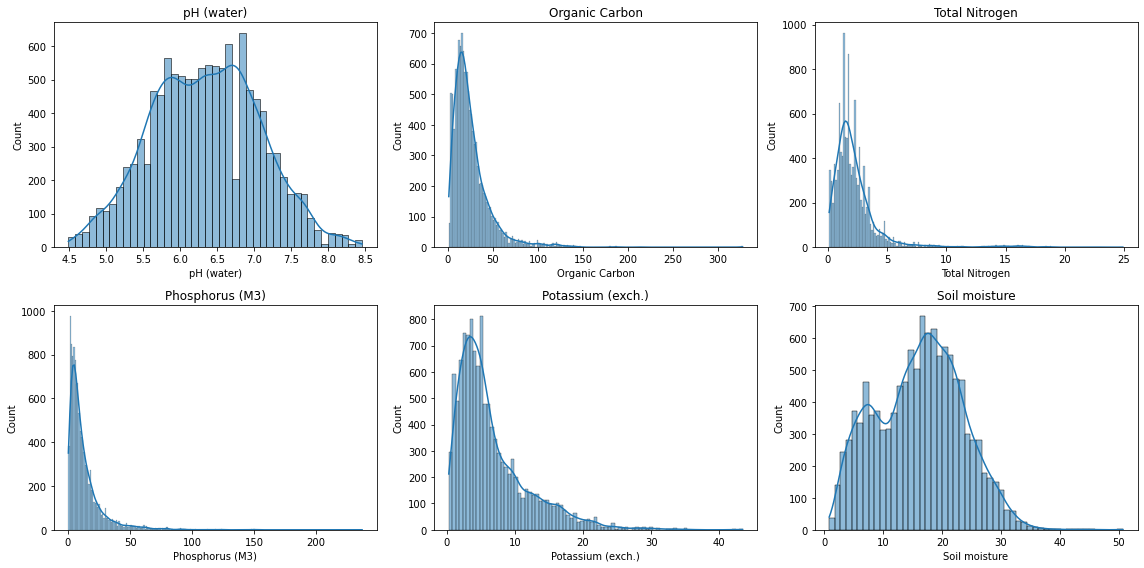

In [118]:
soil_features = ['pH (water)', 'Organic Carbon', 'Total Nitrogen',
                  'Phosphorus (M3)', 'Potassium (exch.)', 'Soil moisture']

fig, axes = plt.subplots(2, 3, figsize=(16,8))
for ax, col in zip(axes.flatten(), soil_features):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

- Insight 

The pH (water) variable exhibited an approximately normal distribution, while Organic Carbon, Total Nitrogen, Phosphorus (M3), and Potassium (exchangeable) showed pronounced positive skewness with long right tails,

#### Visualization 2: Correlation Heatmap

The correlation heat map will show the strength of the relationship between numerical variables

In [119]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)
plt.title('Correlation heatmap')
plt.savefig("images/correlation_heatmap.png", bbox_inches='tight', dpi=150)
plt.show() 

TypeError: corr() got an unexpected keyword argument 'numeric_only'

<Figure size 576x432 with 0 Axes>

The correlation heatmap shows that Organic Carbon and Total Nitrogen have a very strong positive correlation of 0.92, indicating that these two soil properties tend to increase together. The Target Yield variable has very weak linear correlations with the numerical soil features. This suggests that crop yield is influenced by a combination of factors rather than a single soil property.

#### Visualization 3: Crop type distribution

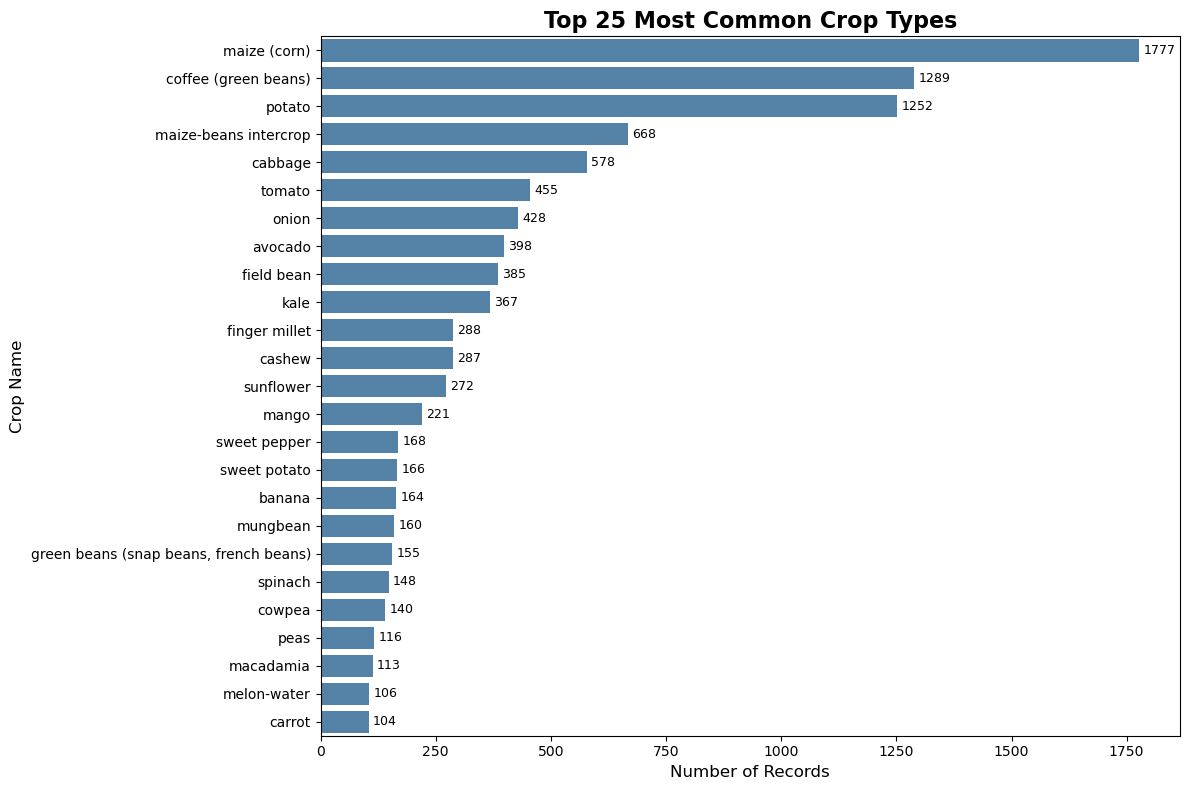

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

top_25 = df["Crop Name"].value_counts().head(25)

fig, ax = plt.subplots(figsize=(12, 8))

bars = sns.barplot(
    x=top_25.values,
    y=top_25.index,
    ax=ax,
    color='steelblue'
)

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3, fontsize=9)

ax.set_title("Top 25 Most Common Crop Types", fontsize=16, fontweight='bold')
ax.set_xlabel("Number of Records", fontsize=12)
ax.set_ylabel("Crop Name", fontsize=12)

plt.tight_layout()
plt.show()

- Insight, from the above observation, it was noted that maize had significantly high number of records followed by green beans and potato with the least being melon-water and carrot respectively within top 25.

#### Visualization 4: Scatterplot

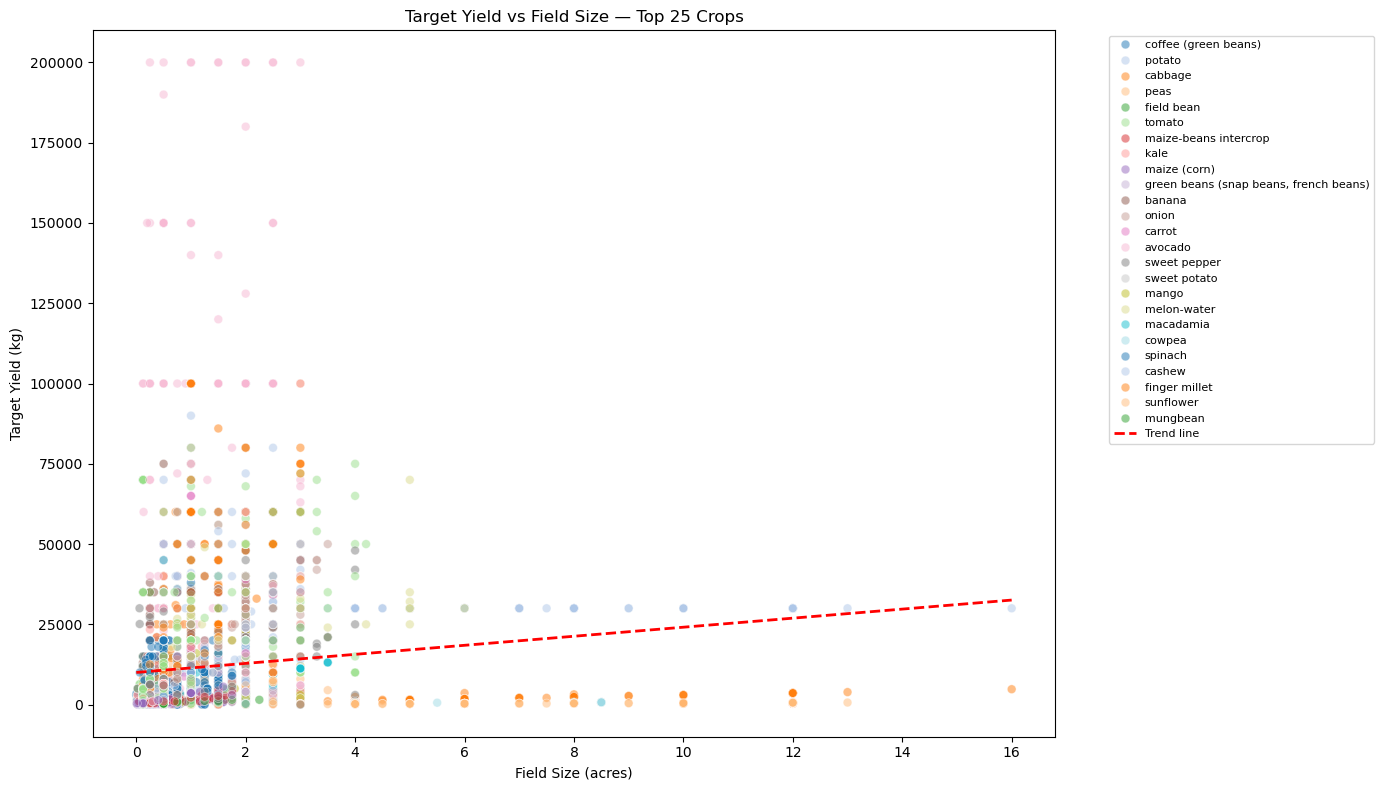

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

top_25_crops = df['Crop Name'].value_counts().head(25).index
df_top25 = df[df['Crop Name'].isin(top_25_crops)]

plt.figure(figsize=(14, 8))

sns.scatterplot(
    data=df_top25,
    x='Field Size',
    y='Target Yield',
    hue='Crop Name',
    alpha=0.5,
    s=40,
    palette='tab20'
)

# Linear trend line 
m, b = np.polyfit(df_top25['Field Size'], df_top25['Target Yield'], 1)

x_range = np.linspace(
    df_top25['Field Size'].min(),
    df_top25['Field Size'].max(),
    200
)

plt.plot(
    x_range,
    m * x_range + b,
    color='red',
    linewidth=2,
    linestyle='--',
    label='Trend line'
)

plt.xlabel("Field Size (acres)")
plt.ylabel("Target Yield (kg)")
plt.title("Target Yield vs Field Size — Top 25 Crops")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

- Insight 

The scatter plot indicates a weak positive association between field size and target yield, with larger fields generally producing higher yields. However, the substantial dispersion of observations around the regression line suggests that field size alone explains only a small proportion of the variation in yield.

The trend line slopes upward, which indicates that

As field size increases, target yield tends to increase on average.This is a positive relationship between field size and target yield

## 3. Data Preparation

### 3.1 Feature Selection

In [ ]:
df .columns

Index(['Crop Name', 'Target Yield', 'Field Size', 'pH (water)',
       'Organic Carbon', 'Total Nitrogen', 'Phosphorus (M3)',
       'Potassium (exch.)', 'Soil moisture'],
      dtype='object')

### 3.2 Defining Features and Target Variable

In [ ]:
# Input variables
X = df.drop("Target Yield", axis=1)

# Target variable
# y = df["Target Yield"]
# We use log transformation to reduce skewness and improve the learning process of the model.
y = np.log1p(df["Target Yield"])

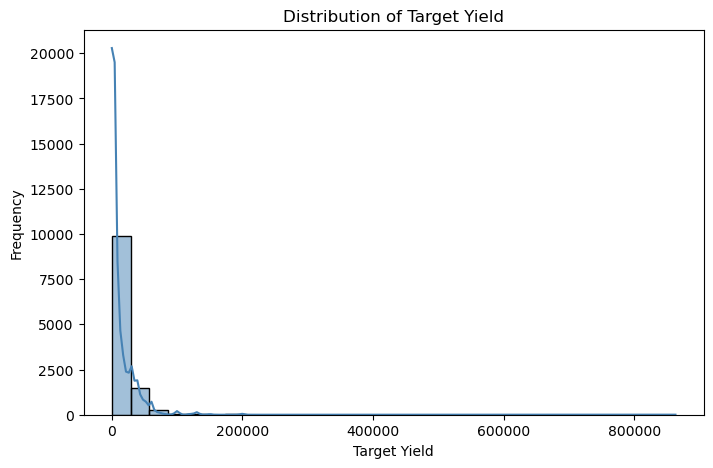

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

sns.histplot(
    df["Target Yield"],
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Target Yield")
plt.xlabel("Target Yield")
plt.ylabel("Frequency")
plt.show()

The plot above proves that our target yield is very skewed. This shows the need of transforming the target yield to reduce skewness and improve the learning process of the model. Later we will convert the predictions back to the original scale using expm1.

### 3.3 Encoding Categorical Variable

We implement One Hot Encoding because Machine learning models cannot process text data directly.

In [ ]:
# Converting the Crop Name into numerical variables
# We add the drop_first=True to remove the perfect collinearity.
X = pd.get_dummies(X, columns=["Crop Name"], dtype=int, drop_first= True)

X.head()

,Field Size,pH (water),Organic Carbon,Total Nitrogen,Phosphorus (M3),Potassium (exch.),Soil moisture,Crop Name_apple,Crop Name_arabica juvenile,Crop Name_avocado,...,Crop Name_sweet potato,Crop Name_tea,Crop Name_thyme,Crop Name_timber (general),Crop Name_tobacco,Crop Name_tomato,Crop Name_tree tomato (tamarillo),Crop Name_vetch,Crop Name_wheat,Crop Name_white bean
0,1.00,5.5,25.9,1.9,2.0,3.8,17.4,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0.75,5.6,29.4,2.2,7.0,4.4,18.8,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2.50,6.0,37.2,3.9,30.5,6.9,20.2,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2.50,6.0,37.2,3.9,30.5,6.9,20.2,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2.50,6.0,37.2,3.9,30.5,6.9,20.2,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
X.shape

(11783, 88)

In [ ]:
X.columns

Index(['Field Size', 'pH (water)', 'Organic Carbon', 'Total Nitrogen',
       'Phosphorus (M3)', 'Potassium (exch.)', 'Soil moisture',
       'Crop Name_apple', 'Crop Name_arabica juvenile', 'Crop Name_avocado',
       'Crop Name_banana', 'Crop Name_barley', 'Crop Name_basil',
       'Crop Name_beet root', 'Crop Name_broccoli', 'Crop Name_butternut',
       'Crop Name_cabbage', 'Crop Name_carrot', 'Crop Name_cashew',
       'Crop Name_cassava', 'Crop Name_cauliflower', 'Crop Name_chickpea',
       'Crop Name_chillies', 'Crop Name_coffee (cherry)',
       'Crop Name_coffee (green beans)', 'Crop Name_cowpea',
       'Crop Name_cucumber', 'Crop Name_cut flowers', 'Crop Name_eggplant',
       'Crop Name_field bean', 'Crop Name_finger millet', 'Crop Name_garlic',
       'Crop Name_ginger', 'Crop Name_grapes',
       'Crop Name_green beans (snap beans, french beans)',
       'Crop Name_groundnut', 'Crop Name_immature oil palm', 'Crop Name_kale',
       'Crop Name_kiwi', 'Crop Name_lentil', '

After one hot encoding it is seen that 82 new columns were added to the existing 7 columns. The 82 new columns are for the 82 crop types in our data.

### 3.4 Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### 3.5 Feature Scaling

In [ ]:
# We use ColumnTransformer to apply StandardScaler only to the 7 continuous numeric columns. 
# We leave the one-hot encoded crop columns unscaled.
# There were some crops with less than 3 rows so scaling them would produce extreme values that destabilize the model.
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

numeric_cols = [
    "Field Size",
    "pH (water)",
    "Organic Carbon",
    "Total Nitrogen",
    "Phosphorus (M3)",
    "Potassium (exch.)",
    "Soil moisture"
]

# Everything else passes through unscaled
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols)
    ],
    remainder="passthrough"
)


#Scaling the training features
X_train_scaled = preprocessor.fit_transform(X_train)

#Scaling the test features
X_test_scaled = preprocessor.transform(X_test)

## 4. Modelling

### 4.1 Linear Regression (Baseline Model)

In [ ]:
# We use Ridge Regression instead of plain Linear Regression as the baseline.
# Ridge adds an L2 penalty that makes the model more stable and less sensitive to the sparse.
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, root_mean_squared_error

linear_model = Ridge(alpha=1.0, random_state=42)

# Training the model
linear_model.fit(X_train_scaled, y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,42


In [ ]:
# Predicting Crop Yield
y_pred_linear = linear_model.predict(X_test_scaled)

# Evaluating the model
linear_mae = mean_absolute_error(y_test, y_pred_linear)
linear_mse = mean_squared_error(y_test, y_pred_linear)
linear_rmse = root_mean_squared_error(y_test, y_pred_linear)
linear_r2 = r2_score(y_test, y_pred_linear)

linear_results = pd.DataFrame({
    "Metric": ["Mean Absolute Error (MAE)", "Mean Squared Error (MSE)", "Root Mean Squared Error (RMSE)", "R² Score"],
    "Value": [linear_mae, linear_mse, linear_rmse, linear_r2]
})

linear_results

,Metric,Value
0,Mean Absolute Error (MAE),0.940525
1,Mean Squared Error (MSE),1.682980
2,Root Mean Squared Error (RMSE),1.297297
3,R² Score,0.479627


### 4.2 Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
)

# Training the model
random_forest_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
# Preddicting crop yield
y_pred_rf = random_forest_model.predict(X_test)

# Evaluating the model
rf_mae = mean_absolute_error(y_test, y_pred_rf)
rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_rmse = root_mean_squared_error(y_test, y_pred_rf)
rf_r2 = r2_score(y_test, y_pred_rf)

rf_results = pd.DataFrame({
    "Metric": ["Mean Absolute Error (MAE)", "Mean Squared Error (MSE)", "Root Mean Squared Error (RMSE)", "R² Score"],
    "Value": [rf_mae, rf_mse, rf_rmse, rf_r2]
})

rf_results

,Metric,Value
0,Mean Absolute Error (MAE),0.619308
1,Mean Squared Error (MSE),1.067949
2,Root Mean Squared Error (RMSE),1.033416
3,R² Score,0.669793


### 4.3 XGBoost Regressor

In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Training the model
xgb_model.fit(X_train, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [ ]:
# Predicting crop yield
y_pred_xgb = xgb_model.predict(X_test)

# Evaluating the model
xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_mse = mean_squared_error(y_test, y_pred_xgb)
xgb_rmse = root_mean_squared_error(y_test, y_pred_xgb)
xgb_r2 = r2_score(y_test, y_pred_xgb)

xgb_results = pd.DataFrame({
    "Metric": ["Mean Absolute Error (MAE)", "Mean Squared Error (MSE)", "Root Mean Squared Error (RMSE)", "R² Score"],
    "Value": [xgb_mae, xgb_mse, xgb_rmse, xgb_r2]
})  

xgb_results

,Metric,Value
0,Mean Absolute Error (MAE),0.658863
1,Mean Squared Error (MSE),1.084180
2,Root Mean Squared Error (RMSE),1.041240
3,R² Score,0.664774


### 4.4 Model Tuning

#### 4.4.1 Hyperparameter Tuning (Random Forest)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Defining the parameter grid
rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# Setting up the randomized search
rf_grid_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=rf_param_grid,
    n_iter=20,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    random_state=42
)

# Training the model
rf_grid_search.fit(X_train, y_train)

print("Best parameters:", rf_grid_search.best_params_)

Best parameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 30}


In [ ]:
# Predicting crop yield
rf_tuned_model = rf_grid_search.best_estimator_
y_pred_rf_tuned = rf_tuned_model.predict(X_test)

# Evaluating the model
rf_tuned_mae = mean_absolute_error(y_test, y_pred_rf_tuned)
rf_tuned_mse = mean_squared_error(y_test, y_pred_rf_tuned)
rf_tuned_rmse = root_mean_squared_error(y_test, y_pred_rf_tuned)
rf_tuned_r2 = r2_score(y_test, y_pred_rf_tuned)

rf_tuned_results = pd.DataFrame({
    "Metric": ["Mean Absolute Error (MAE)", "Mean Squared Error (MSE)", "Root Mean Squared Error (RMSE)", "R² Score"],
    "Value": [rf_tuned_mae, rf_tuned_mse, rf_tuned_rmse, rf_tuned_r2]
})

rf_tuned_results

,Metric,Value
0,Mean Absolute Error (MAE),0.633935
1,Mean Squared Error (MSE),1.083769
2,Root Mean Squared Error (RMSE),1.041042
3,R² Score,0.664901


#### 4.4.2 Hyperparameter Tuning (XGBoost)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Defining the parameter grid
xgb_param_grid = {
    "n_estimators": [100, 300],
    "learning_rate": [0.05, 0.1],
    "max_depth": [4, 6, 8],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

# Setting up the randomized search
xgb_grid_search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_distributions=xgb_param_grid,
    n_iter=20,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    random_state=42
)

# Training the model
xgb_grid_search.fit(X_train, y_train)

print("Best parameters:", xgb_grid_search.best_params_)

Best parameters: {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


In [ ]:
# Predicting crop yield
xgb_tuned_model = xgb_grid_search.best_estimator_
y_pred_xgb_tuned = xgb_tuned_model.predict(X_test)

# Evaluating the model
xgb_tuned_mae = mean_absolute_error(y_test, y_pred_xgb_tuned)
xgb_tuned_mse = mean_squared_error(y_test, y_pred_xgb_tuned)
xgb_tuned_rmse = root_mean_squared_error(y_test, y_pred_xgb_tuned)
xgb_tuned_r2 = r2_score(y_test, y_pred_xgb_tuned)

xgb_tuned_results = pd.DataFrame({
    "Metric": ["Mean Absolute Error (MAE)", "Mean Squared Error (MSE)", "Root Mean Squared Error (RMSE)", "R² Score"],
    "Value": [xgb_tuned_mae, xgb_tuned_mse, xgb_tuned_rmse, xgb_tuned_r2]
})

xgb_tuned_results

,Metric,Value
0,Mean Absolute Error (MAE),0.692099
1,Mean Squared Error (MSE),1.134258
2,Root Mean Squared Error (RMSE),1.065015
3,R² Score,0.649290


### 4.5 F-T Transformer

In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

# Keeping the model reproducible
torch.manual_seed(42)
np.random.seed(42)

# Converting the scaled features to tensors
X_train_ft = torch.tensor(np.asarray(X_train_scaled, dtype=np.float32), dtype=torch.float32)
X_test_ft = torch.tensor(np.asarray(X_test_scaled, dtype=np.float32), dtype=torch.float32)
y_train_ft = torch.tensor(y_train.to_numpy(dtype=np.float32), dtype=torch.float32).view(-1, 1)

t_train_dataset = TensorDataset(X_train_ft, y_train_ft)
t_train_loader = DataLoader(t_train_dataset, batch_size=64, shuffle=True)

class FTTransformerRegressor(nn.Module):
    def __init__(self, input_dim, d_model=32, n_heads=4, n_layers=1, dropout=0.1):
        super().__init__()
        self.feature_tokenizer = nn.Linear(1, d_model)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_model * 2,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        tokens = self.feature_tokenizer(x.unsqueeze(-1))
        cls_token = self.cls_token.expand(x.size(0), -1, -1)
        tokens = torch.cat([cls_token, tokens], dim=1)
        encoded = self.encoder(tokens)
        return self.head(encoded[:, 0, :])

# Training the model
ft_model = FTTransformerRegressor(X_train_ft.shape[1])
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(ft_model.parameters(), lr=0.001, weight_decay=1e-4)

epochs = 10
ft_model.train()
for epoch in range(epochs):
    running_loss = 0.0
    for batch_x, batch_y in t_train_loader:
        optimizer.zero_grad()
        predictions = ft_model(batch_x)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch + 1}/{epochs} | Loss: {running_loss / len(t_train_loader):.4f}")

Epoch 5/10 | Loss: 3.8773
Epoch 10/10 | Loss: 3.8460


In [ ]:
# Predicting crop yield
ft_model.eval()
with torch.no_grad():
    y_pred_ft = ft_model(X_test_ft).squeeze().cpu().numpy()

# Evaluating the model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

ft_mae = mean_absolute_error(y_test, y_pred_ft)
ft_mse = mean_squared_error(y_test, y_pred_ft)
ft_rmse = root_mean_squared_error(y_test, y_pred_ft)
ft_r2 = r2_score(y_test, y_pred_ft)

ft_results = pd.DataFrame({
    "Metric": ["Mean Absolute Error (MAE)", "Mean Squared Error (MSE)", "Root Mean Squared Error (RMSE)", "R² Score"],
    "Value": [ft_mae, ft_mse, ft_rmse, ft_r2]
})

ft_results

,Metric,Value
0,Mean Absolute Error (MAE),1.424509
1,Mean Squared Error (MSE),3.203579
2,Root Mean Squared Error (RMSE),1.789854
3,R² Score,0.009462


The FT Transformer model underperformed because of the small dataset and limited feature complexity. 
Transformer model normally require substantially larger datasets (>100,000) than tree-based ensemble methods.

## 5. Evaluation

### 5.1 Model Comparison

The model with the lowest MAE and RMSE and the highest R2 Score is considered the best performing model

In [ ]:
# Creating a DataFrame containing the evaluation metrics
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost",
        "Random Forest (Tuned)",
        "XGBoost (Tuned)",
        "F-T Transformer"
    ],

    "MAE": [
        linear_mae,
        rf_mae,
        xgb_mae,
        rf_tuned_mae,
        xgb_tuned_mae,
        ft_mae
    ],

    "MSE": [
        linear_mse,
        rf_mse,
        xgb_mse,
        rf_tuned_mse,
        xgb_tuned_mse,
        ft_mse
    ],

    "RMSE": [
        linear_rmse,
        rf_rmse,
        xgb_rmse,
        rf_tuned_rmse,
        xgb_tuned_rmse,
        ft_rmse
    ],

    "R² Score": [
        linear_r2,
        rf_r2,
        xgb_r2,
        rf_tuned_r2,
        xgb_tuned_r2,
        ft_r2
        ]
})

# Round the values to 2 decimal places
model_comparison = model_comparison.round(2)

model_comparison

,Model,MAE,MSE,RMSE,R² Score
0,Linear Regression,0.94,1.68,1.30,0.48
1,Random Forest,0.62,1.07,1.03,0.67
2,XGBoost,0.66,1.08,1.04,0.66
3,Random Forest (Tuned),0.63,1.08,1.04,0.66
4,XGBoost (Tuned),0.69,1.13,1.07,0.65
5,F-T Transformer,1.42,3.20,1.79,0.01


### 5.2 Best Performing Model

In [ ]:
# Find the model with the highest R² Score
best_model = model_comparison.loc[
    model_comparison["R² Score"].idxmax()
]

print("Best Performing Model")
print(best_model)

Best Performing Model
Model       Random Forest
MAE                  0.62
MSE                  1.07
RMSE                 1.03
R² Score             0.67
Name: 1, dtype: object


## 6. Model Interpretation

#### 6.1 Feature Importance

In [ ]:
# Creating a dataframe that has feature names and importance scores
best_feature_importance = pd.DataFrame ({
    "Feature": X_train.columns,
    "Importance": random_forest_model.feature_importances_
})

# Sorting
best_feature_importance= best_feature_importance.sort_values(
    by= "Importance",
    ascending = False
)

# Convert feature importance scores into percentages
best_feature_importance["Importance (%)"] = (
    best_feature_importance["Importance"] * 100
)

# Round the percentages to two decimal places
best_feature_importance["Importance (%)"] = (
    best_feature_importance["Importance (%)"].round(2)
)

# Displaying the top 20 most important features
best_feature_importance.head(20)

,Feature,Importance,Importance (%)
0,Field Size,0.166416,16.64
76,Crop Name_sunflower,0.076974,7.70
43,Crop Name_maize (corn),0.074633,7.46
6,Soil moisture,0.071446,7.14
5,Potassium (exch.),0.070716,7.07
1,pH (water),0.063893,6.39
4,Phosphorus (M3),0.063471,6.35
2,Organic Carbon,0.056129,5.61
3,Total Nitrogen,0.042967,4.30
44,Crop Name_maize-beans intercrop,0.041583,4.16


#### Visualization

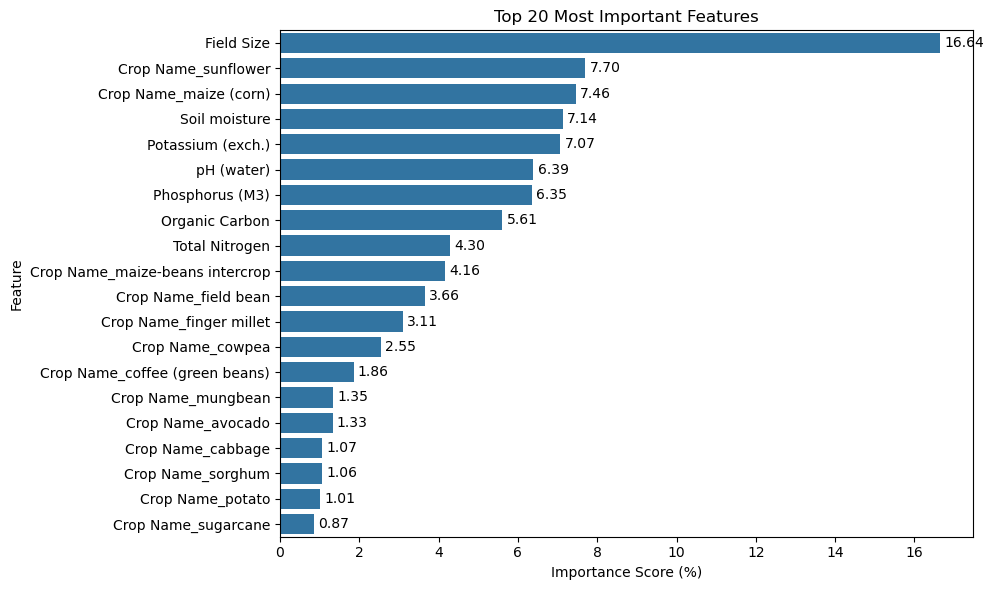

In [ ]:
# Visualizing the top 20 most important features

top_20_features = best_feature_importance.head(20)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=top_20_features,
    x="Importance (%)",
    y="Feature"
)

# Add values to each bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f',
        padding=3,
        fontsize=10
    )

plt.title("Top 20 Most Important Features")
plt.xlabel("Importance Score (%)")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

* The Feature importance analysis shows that Field size was the most influential variable in predicting crop yield contributing 16.64% of the model's decision making process. Followed by Sunflower crop (7.7%), Maize crop(7.46%), Soil moisture (7.16%), Potassium (7.08%), pH (6.39%), Phosphrus (6.32%), Organic Carbon (5.62%) and Nitrogen with 4.32%.
* This shows that the size of the cultivated land has the biggest impact on the expected crop yield.
* From the crop perspective, sunflower and maize were the most influential crops suggesting that apart from field size, the type of crop you plant  can also determine the crop yield.
* Soil moisture, Potassium, pH, Phosphorus , Organic Carbon and Nitrogen were also identified as important soil-related factors that influenced the model prediction.

### 6.2 Actual Vs Predicted Values

In [ ]:
# Converting the target variable back to its original scale.

# Actual crop yield
y_test_original= np.expm1(y_test)

# Predicted crop yield from the best model (Random Forest)
y_pred_original= np.expm1(y_pred_rf)

In [ ]:
# Recover the crop names from the one-hot encoded columns
crop_columns = [col for col in X_test.columns if col.startswith("Crop Name_")]

crop_names = (
    X_test[crop_columns]
    .idxmax(axis=1)
    .str.replace("Crop Name_", "", regex=False)
)

In [ ]:
# Comparison table to compare the actual and predicted crop yields
comparison= pd.DataFrame({
    "Crop Name": crop_names,
    "Actual Yield (kg)": y_test_original,
    "Predicted Yield (kg)": y_pred_original
})

comparison["Error"]= (
    comparison["Predicted Yield (kg)"] - comparison["Actual Yield (kg)"]
)

comparison["Absolute Error"]= comparison["Error"].abs()

comparison["Percentage Error (%)"]= (
    comparison["Absolute Error"] / comparison["Actual Yield (kg)"] * 100
)
comparison["Percentage Error (%)"]= comparison["Percentage Error (%)"].round(1)

comparison.head(20)

,Crop Name,Actual Yield (kg),Predicted Yield (kg),Error,Absolute Error,Percentage Error (%)
2507,finger millet,600.0,600.000000,1.591616e-12,1.591616e-12,0.0
11483,field bean,270.0,317.831970,4.783197e+01,4.783197e+01,17.7
4207,maize (corn),180.0,176.135625,-3.864375e+00,3.864375e+00,2.1
1935,onion,40000.0,27309.128998,-1.269087e+04,1.269087e+04,31.7
8990,coffee (green beans),2000.0,2052.293915,5.229391e+01,5.229391e+01,2.6
2996,kale,6500.0,6297.304846,-2.026952e+02,2.026952e+02,3.1
10014,soybean,1200.0,1392.631535,1.926315e+02,1.926315e+02,16.1
10714,potato,7500.0,7457.319597,-4.268040e+01,4.268040e+01,0.6
8147,mungbean,1200.0,1223.929460,2.392946e+01,2.392946e+01,2.0
1722,mint,2500.0,1780.737784,-7.192622e+02,7.192622e+02,28.8


In [ ]:
comparison[comparison["Crop Name"] == "maize (corn)"]

,Crop Name,Actual Yield (kg),Predicted Yield (kg),Error,Absolute Error,Percentage Error (%)
4207,maize (corn),180.0,176.135625,-3.864375e+00,3.864375e+00,2.1
9370,maize (corn),30.0,3142.575004,3.112575e+03,3.112575e+03,10375.3
9066,maize (corn),3200.0,3280.161591,8.016159e+01,8.016159e+01,2.5
2021,maize (corn),540.0,721.785269,1.817853e+02,1.817853e+02,33.7
9039,maize (corn),3200.0,4080.180857,8.801809e+02,8.801809e+02,27.5
...,...,...,...,...,...,...
3794,maize (corn),180.0,513.066991,3.330670e+02,3.330670e+02,185.0
6073,maize (corn),5400.0,4529.620230,-8.703798e+02,8.703798e+02,16.1
4807,maize (corn),3600.0,3647.456591,4.745659e+01,4.745659e+01,1.3
1889,maize (corn),200.0,382.398007,1.823980e+02,1.823980e+02,91.2


In [ ]:
df[df["Crop Name"]=="maize (corn)"]["Target Yield"].describe()

count    1777.000000
mean     1559.512662
std      1485.696328
min         1.000000
25%       500.000000
50%       900.000000
75%      2500.000000
max      8000.000000
Name: Target Yield, dtype: float64

* From the comparison table above the Random Forest Model gives predictions that closely match the actual yields. 
* However, there were a few instances that showed large prediction errors such as maize where it had an actual yield of 30kg but the predicted yield was approximately 3061kg.
* Such observations are rare within the dataset and are likely influenced by other external factors that were not represented in the features of this dataset. Example, a farmer from Kiambu with the same soil characteristics and field size from a farmer in Rongai may have different yield due to factors such as rainfall, pest infestation, diseases or other environmental conditions.
* This therefore does not mean the predictions are innacurate, rather that other features that were not included in the dataset may take part in influencing the outcome.

#### Visualization

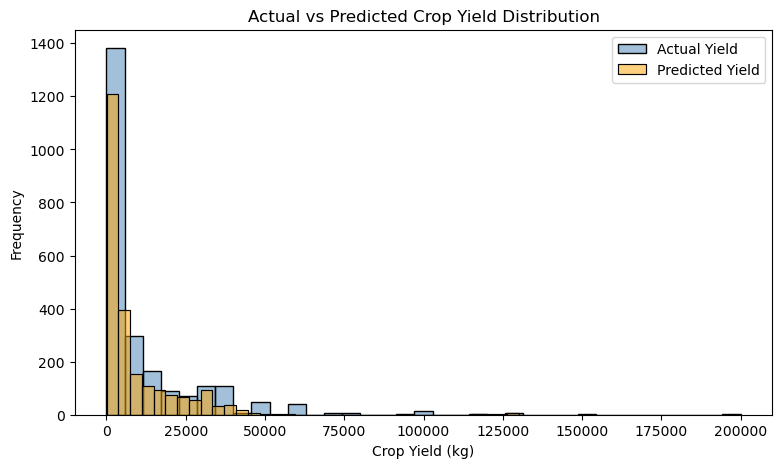

In [ ]:
# Actual vs Predicted Crop Yield Histogram Plot
plt.figure(figsize=(9,5))

sns.histplot(
    y_test_original,
    bins=35,
    color="steelblue",
    alpha=0.5,
    label="Actual Yield"
)

sns.histplot(
    y_pred_original,
    bins=35,
    color="orange",
    alpha=0.5,
    label="Predicted Yield"
)

plt.title("Actual vs Predicted Crop Yield Distribution")
plt.xlabel("Crop Yield (kg)")
plt.ylabel("Frequency")
plt.legend()

plt.show()

From the Histogram above it is observed that the Random Forest Model gives predictions that closely match the actual yields.

## 7. Crop Recommendation System

In [ ]:
import ipywidgets as widgets

from IPython.display import display, clear_output

# Prepare farmer input for the trained model
def prepare_crop_input(
    crop_name,
    field_size,
    ph,
    organic_carbon,
    total_nitrogen,
    phosphorus,
    potassium,
    soil_moisture
):

    # Creating one row containing zero for every model feature
    input_data = pd.DataFrame(
        np.zeros((1, len(X.columns))),
        columns=X.columns
    )

    # Add the numerical input values
    input_data.loc[0, "Field Size"] = field_size
    input_data.loc[0, "pH (water)"] = ph
    input_data.loc[0, "Organic Carbon"] = organic_carbon
    input_data.loc[0, "Total Nitrogen"] = total_nitrogen
    input_data.loc[0, "Phosphorus (M3)"] = phosphorus
    input_data.loc[0, "Potassium (exch.)"] = potassium
    input_data.loc[0, "Soil moisture"] = soil_moisture

    # Creating the one-hot encoded column name for the selected crop
    crop_column = f"Crop Name_{crop_name}"

    # Set the selected crop column to 1
    if crop_column in input_data.columns:
        input_data.loc[0, crop_column] = 1

    # Ensure the columns remain in exactly the same order
    input_data = input_data[X.columns]

    return input_data


# Crop yield prediction function using the trained Random Forest model
def predict_crop_yield(
    crop_name,
    field_size,
    ph,
    organic_carbon,
    total_nitrogen,
    phosphorus,
    potassium,
    soil_moisture
):

    # Prepare the farmer's input
    input_data = prepare_crop_input(
        crop_name=crop_name,
        field_size=field_size,
        ph=ph,
        organic_carbon=organic_carbon,
        total_nitrogen=total_nitrogen,
        phosphorus=phosphorus,
        potassium=potassium,
        soil_moisture=soil_moisture
    )

    # The model predicts log(Target Yield + 1)
    predicted_log_yield = random_forest_model.predict(input_data)[0]

    # Convert the prediction back to the original yield scale
    predicted_yield = np.expm1(predicted_log_yield)

    # Crop yield should not be negative
    predicted_yield = max(0, predicted_yield)

    return predicted_yield


# Predict the crop yield of the selected crop and recommend alternatives
def predict_and_recommend(
    crop_name,
    field_size,
    ph,
    organic_carbon,
    total_nitrogen,
    phosphorus,
    potassium,
    soil_moisture
):

    # Predict crop yield for the crop selected by the farmer
    selected_crop_yield = predict_crop_yield(
        crop_name=crop_name,
        field_size=field_size,
        ph=ph,
        organic_carbon=organic_carbon,
        total_nitrogen=total_nitrogen,
        phosphorus=phosphorus,
        potassium=potassium,
        soil_moisture=soil_moisture
    )

    alternative_predictions = []

    # Test every other crop under the same field size and soil conditions
    for alternative_crop in sorted(df["Crop Name"].unique()):

        # Skip the crop already selected by the farmer
        if alternative_crop == crop_name:
            continue

        alternative_yield = predict_crop_yield(
            crop_name=alternative_crop,
            field_size=field_size,
            ph=ph,
            organic_carbon=organic_carbon,
            total_nitrogen=total_nitrogen,
            phosphorus=phosphorus,
            potassium=potassium,
            soil_moisture=soil_moisture
        )

        alternative_predictions.append({
            "Crop Name": alternative_crop,
            "Predicted Yield (kg)": alternative_yield
        })

    # Convert alternative results into a DataFrame
    recommendations = pd.DataFrame(alternative_predictions)

    # Sort from the highest predicted yield to the lowest
    recommendations = recommendations.sort_values(
        by="Predicted Yield (kg)",
        ascending=False
    ).reset_index(drop=True)

    # Keep only crops predicted to yield more than the selected crop
    better_alternatives = recommendations[
        recommendations["Predicted Yield (kg)"] > selected_crop_yield
    ].copy()

    # Calculate the expected increase
    better_alternatives["Expected Increase (kg)"] = (
        better_alternatives["Predicted Yield (kg)"] -
        selected_crop_yield
    )

    better_alternatives["Expected Increase (%)"] = (
        better_alternatives["Expected Increase (kg)"] /
        selected_crop_yield
    ) * 100 if selected_crop_yield > 0 else 0

    return selected_crop_yield, recommendations, better_alternatives



# Creating a search fuctionality for crop name and soil input fields
available_crops = sorted(df["Crop Name"].dropna().unique().tolist())

# Searchable crop dropdown so that the user can see crops available in our dataset
crop_input = widgets.Combobox(
    placeholder="Search for a crop...",
    options=available_crops,
    description="Crop:",
    ensure_option=True,
    disabled=False,
    layout=widgets.Layout(width="500px")
)

# Field size input
field_size_input = widgets.FloatText(
    value=None,
    description="Field Size (> 0 acres):",
    tooltip="Enter the field size in acres.",
    style={"description_width": "180px"},
    layout=widgets.Layout(width="500px")
)

# Soil pH: accepted range 3–10
ph_input = widgets.FloatText(
    value=None,
    description="Soil pH (3–10):",
    tooltip="Enter a soil pH value between 3 and 10.",
    style={"description_width": "180px"},
    layout=widgets.Layout(width="500px")
)

# Organic Carbon 
organic_carbon_input = widgets.FloatText(
    value=None,
    description="Organic Carbon (g/kg):",
    tooltip="Enter the Organic Carbon measurement in g/kg.",
    style={"description_width": "180px"},
    layout=widgets.Layout(width="500px")
)

# Nitrogen: accepted range 0–5%
nitrogen_input = widgets.FloatText(
    value=None,
    description="Nitrogen (0–5%):",
    tooltip="Enter the Nitrogen measurement between 0 and 5%.",
    style={"description_width": "180px"},
    layout=widgets.Layout(width="500px")
)

# Phosphorus: accepted range 0–200 ppm
phosphorus_input = widgets.FloatText(
    value=None,
    description="Phosphorus (0–200 ppm):",
    tooltip="Enter the Phosphorus measurement between 0 and 200 ppm.",
    style={"description_width": "180px"},
    layout=widgets.Layout(width="500px")
)

# Potassium: accepted range 0–10 meq%
potassium_input = widgets.FloatText(
    value=None,
    description="Potassium (0–10 meq%):",
    tooltip="Enter the Potassium measurement between 0 and 10 meq%.",
    style={"description_width": "180px"},
    layout=widgets.Layout(width="500px")
)

# Soil moisture: percentage
soil_moisture_input = widgets.FloatText(
    value=None,
    description="Soil Moisture (0–100%):",
    tooltip="Enter the Soil Moisture percentage between 0 and 100.",
    style={"description_width": "180px"},
    layout=widgets.Layout(width="500px")
)

# Prediction button
predict_button = widgets.Button(
    description="Predict and Recommend",
    button_style="success",
    icon="leaf",
    layout=widgets.Layout(width="250px", height="45px")
)

# Area where results will be displayed
output_area = widgets.Output()


# Validating inputs and display the prediction
def run_prediction(button):

    with output_area:

        clear_output()

        crop_name = crop_input.value
        field_size = field_size_input.value
        ph = ph_input.value
        organic_carbon = organic_carbon_input.value
        total_nitrogen = nitrogen_input.value
        phosphorus = phosphorus_input.value
        potassium = potassium_input.value
        soil_moisture = soil_moisture_input.value

    
        # Validate the inputs
        errors = []

        if crop_name not in available_crops:
            errors.append(
                "Please search for and select a valid crop from the list."
            )

        if field_size <= 0:
            errors.append(
                "Field size must be greater than zero acres."
            )

        if not 3 <= ph <= 10:
            errors.append(
                "Soil pH must be between 3 and 10."
            )

        # Organic Carbon validation based on the cleaned dataset
        organic_carbon_min = float(df["Organic Carbon"].min())
        organic_carbon_max = float(df["Organic Carbon"].max())

        if not organic_carbon_min <= organic_carbon <= organic_carbon_max:
            errors.append(
                f"Organic Carbon must be between "
                f"{organic_carbon_min:.1f} and {organic_carbon_max:.1f} g/kg."
            )

        if not 0 <= total_nitrogen <= 5:
            errors.append(
                "Nitrogen must be between 0 and 5%."
            )

        if not 0 <= phosphorus <= 200:
            errors.append(
                "Phosphorus must be between 0 and 200 ppm."
            )

        if not 0 <= potassium <= 10:
            errors.append(
                "Potassium must be between 0 and 10 meq%."
            )

        if not 0 <= soil_moisture <= 100:
            errors.append(
                "Soil moisture must be between 0 and 100%."
            )

    

        if errors:
            print("Please correct the following input errors:\n")

            for error in errors:
                print(f"• {error}")

            return

    
        # Generate prediction and recommendation
        selected_yield, all_recommendations, better_alternatives = (
            predict_and_recommend(
                crop_name=crop_name,
                field_size=field_size,
                ph=ph,
                organic_carbon=organic_carbon,
                total_nitrogen=total_nitrogen,
                phosphorus=phosphorus,
                potassium=potassium,
                soil_moisture=soil_moisture
            )
        )

        # Display the farmer's requested prediction
        print("FARMER'S SELECTED CROP\n")

        selected_result = pd.DataFrame({
            "Crop Name": [crop_name],
            "Field Size (acres)": [field_size],
            "Predicted Yield (kg)": [selected_yield]
        })

        display(selected_result.round(2))

        print("\nSOIL INFORMATION USED\n")

        soil_information = pd.DataFrame({
            "Soil Feature": [
                "Soil pH",
                "Organic Carbon",
                "Nitrogen",
                "Phosphorus",
                "Potassium",
                "Soil Moisture"
            ],
            "Value": [
                ph,
                organic_carbon,
                total_nitrogen,
                phosphorus,
                potassium,
                soil_moisture
            ],
            "Unit": [
                "pH value",
                "g/kg",
                "%",
                "ppm",
                "meq%",
                "%"
            ]
        })

        display(soil_information)

        # Display the recommended alternatives
        if not better_alternatives.empty:

            best_alternative = better_alternatives.iloc[0]

            print("\nRECOMMENDED ALTERNATIVE CROP\n")

            recommended_result = pd.DataFrame({
                "Recommended Crop": [
                    best_alternative["Crop Name"]
                ],
                "Predicted Yield (kg)": [
                    best_alternative["Predicted Yield (kg)"]
                ],
                "Expected Increase (kg)": [
                    best_alternative["Expected Increase (kg)"]
                ],
                "Expected Increase (%)": [
                    best_alternative["Expected Increase (%)"]
                ]
            })

            display(recommended_result.round(1))

            print(
                f"\nBased on the same field size and soil conditions, "
                f"{best_alternative['Crop Name']} is predicted to produce "
                f"a higher yield than {crop_name}."
            )

            print("\nTOP 3 HIGHER-YIELDING ALTERNATIVES\n")

            top_three = better_alternatives.head(3)[[
                "Crop Name",
                "Predicted Yield (kg)",
                "Expected Increase (kg)",
                "Expected Increase (%)"
            ]]

            display(top_three.round(1))

        else:
            print("\nRECOMMENDATION\n")

            print(
                f"The selected crop, {crop_name}, already has the "
                "highest predicted yield under the provided field and "
                "soil conditions."
            )


# Run the function when the button is clicked
predict_button.on_click(run_prediction)


# Display instructions and the input form
instructions = widgets.HTML(
    value=f"""
    <h3>Crop Yield Prediction and Recommendation System</h3>

    <p>
    Search for the crop you intend to grow, then type your field
    size and soil-test results in the fields below.
    </p>

    <h4>Input units and accepted ranges</h4>

    <ul>
        <li><b>Crop:</b> Search and select from crops available in the dataset.</li>
        <li><b>Field Size:</b> Acres; must be greater than 0.</li>
        <li><b>Soil pH:</b> 3–10.</li>
        <li><b>Organic Carbon:</b> g/kg.</li>
        <li><b>Nitrogen:</b> 0–5%.</li>
        <li><b>Phosphorus:</b> 0–200 ppm.</li>
        <li><b>Potassium:</b> 0–10 meq%.</li>
        <li><b>Soil Moisture:</b> 0–100%.</li>
        <li><b>Predicted Yield:</b> kilograms (kg).</li>
    </ul>

    <p>
    The system will first predict the yield of the selected crop.
    It will then recommend a higher-yielding alternative under the
    same field size and soil conditions, where one is available.
    </p>
    """
)

display(
    instructions,
    crop_input,
    field_size_input,
    ph_input,
    organic_carbon_input,
    nitrogen_input,
    phosphorus_input,
    potassium_input,
    soil_moisture_input,
    predict_button,
    output_area
)

HTML(value='\n    <h3>Crop Yield Prediction and Recommendation System</h3>\n\n    <p>\n    Search for the crop…

Combobox(value='', description='Crop:', ensure_option=True, layout=Layout(width='500px'), options=('alfalfa-lu…

FloatText(value=0.0, description='Field Size (> 0 acres):', layout=Layout(width='500px'), style=DescriptionSty…

FloatText(value=0.0, description='Soil pH (3–10):', layout=Layout(width='500px'), style=DescriptionStyle(descr…

FloatText(value=0.0, description='Organic Carbon (g/kg):', layout=Layout(width='500px'), style=DescriptionStyl…

FloatText(value=0.0, description='Nitrogen (0–5%):', layout=Layout(width='500px'), style=DescriptionStyle(desc…

FloatText(value=0.0, description='Phosphorus (0–200 ppm):', layout=Layout(width='500px'), style=DescriptionSty…

FloatText(value=0.0, description='Potassium (0–10 meq%):', layout=Layout(width='500px'), style=DescriptionStyl…

FloatText(value=0.0, description='Soil Moisture (0–100%):', layout=Layout(width='500px'), style=DescriptionSty…

Button(button_style='success', description='Predict and Recommend', icon='leaf', layout=Layout(height='45px', …

Output()

## 8. Findings. 
### 8.1 Data Exploration Findings
* The dataset contained over 10,000 crop records from different crop types and soil conditions, providing enough data to build reliable prediction models.
* Removing missing values, duplicates, and crop-specific outliers improved the quality of the dataset.
* Applying a log transformation to the target yield reduced skewness and made the data more suitable for machine learning.

### 8.2 Model Findings
* Among all the models tested, the Random Forest Regressor achieved the best overall performance with an MAE (0.62), MSE(1.07), RMSE (1.03), and R² Score (0.67)
* The Linear Regression (Ridge) model performed the worst among the traditional machine learning models because it could not capture the complex relationships between soil properties and crop yield.
* The XGBoost model produced results that were similar to Random Forest but performed slightly worse on this dataset.
* Hyperparameter tuning did not improve the performance of either the Random Forest or XGBoost models.
* The F-T Transformer performed poorly, achieving an R² score of approximately 0.01, showing that deep learning was not suitable for this dataset due to its size and feature complexity.
* Feature importance analysis showed that Field Size was the most influential variable in predicting crop yield.
* The Random Forest model produced predictions that were generally close to the actual crop yields, although there were a few crops with extremely high or very low yields had larger prediction errors.

### 8.3 Business Findings
* The recommendation system successfully predicted the crop yield of a farmer's selected crop using the provided soil measurements and field size.
* The recommendation system also identified alternative crops that could produce higher yields under the same soil conditions, helping farmers make more informed planting decisions.

## 9. Recommendations

* Farmers should use this prediction model before planting to estimate the expected crop yield based on their soil properties and field size in order to make informed decisions.
* Farmers should also use the recommendation system to compare different crop options and select crops that are predicted to produce higher yields under the same soil conditions.
* Soil testing should be carried out before planting since soil properties such as soil moisture, pH, organic carbon, nitrogen, phosphorus, and potassium were found to have a significant influence on crop yield.
* Agricultural extension officers can use this system to provide farmers with data-driven advice on crop selection instead of relying only on experience.
* Government agencies and agricultural organizations can integrate this model into digital farming platforms to support food security planning and improve crop production.

## Other Recommendation 


Improve Data Quality: Future data collection should focus on reducing missing values and implementing validation procedures to minimize inaccurate or unrealistic records. Collecting more observations for underrepresented crop types will also improve model reliability and reduce class imbalance.

Incorporate Additional Environmental Variables: Future models should integrate factors such as rainfall, temperature, humidity, irrigation practices, fertilizer application, pest and disease occurrence, and geographic location to enhance prediction accuracy.

Deploy the Random Forest Model: Since the Random Forest model achieved the best predictive performance among all evaluated models, it is recommended as the production model for crop yield prediction applications.

Prioritize Key Predictive Factors: Farmers and agricultural stakeholders should focus on monitoring and managing the most influential variables identified by the model, including field size, crop type, soil moisture, soil pH, nitrogen, phosphorus, potassium, and organic carbon.

Develop a Decision Support System: The predictive model should be implemented as a user-friendly web or mobile application that allows users to input field information, receive crop yield predictions, and obtain practical recommendations for improving soil and crop management.

Provide Action-Oriented Recommendations: Beyond predicting crop yield, future systems should generate personalized recommendations on soil nutrient management, pH adjustment, moisture conservation, and suitable crop selection to support informed farming decisions.

Enhance Future Research: Further work should investigate prediction errors, develop crop-specific prediction models, incorporate satellite and weather data, validate the model across different regions, and continuously retrain the model using newly collected agricultural data to improve its robustness and generalizability
